<a href="https://colab.research.google.com/github/krakenkhan/Data_Mining_Project/blob/main/Data_Mining_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DATA Mining Final Project

In [14]:
!pip install -q ucimlrepo

### Libraries Import
Importing libraries used throughout the Project


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# adjusting  tables to make them readable
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_SEED = 42

The Dataset is a Relative CPU Performance Dataset in terms of cycle time and Memore Size [here](https://archive.ics.uci.edu/dataset/29/computer+hardware)

In [16]:
from ucimlrepo import fetch_ucirepo
dataset = fetch_ucirepo(id=29)

print(dataset.metadata)
print()
print("Variables:")
print(dataset.variables)

{'uci_id': 29, 'name': 'Computer Hardware', 'repository_url': 'https://archive.ics.uci.edu/dataset/29/computer+hardware', 'data_url': 'https://archive.ics.uci.edu/static/public/29/data.csv', 'abstract': 'Relative CPU Performance Data, described in terms of its cycle time, memory size, etc.', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 209, 'num_features': 10, 'feature_types': ['Integer'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1987, 'last_updated': 'Fri Oct 27 2023', 'dataset_doi': '10.24432/C5830D', 'creators': ['Jacob Feldmesser'], 'intro_paper': None, 'additional_info': {'summary': 'The estimated relative performance values were estimated by the authors using a linear regression method.  See their article (pp 308-313) for more details on how the relative performance values were set.', 'purpose': None, 'funded_by': N

This Dataset consists of CPUs that have different Performance speed. It shows us features that correlates to this metric

In [58]:
X = dataset.data.features.copy()
y = dataset.data.targets

# making 1 df to work with
if y is not None and not y.empty:
    df = pd.concat([X, y], axis=1)
else:
    df = X.copy()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (209, 10)
Columns: ['VendorName', 'ModelName', 'MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX', 'PRP', 'ERP']


,VendorName,ModelName,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


In [18]:
# Missing Values and data types
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())

Dtypes:
VendorName    object
ModelName     object
MYCT           int64
MMIN           int64
MMAX           int64
CACH           int64
CHMIN          int64
CHMAX          int64
PRP            int64
ERP            int64
dtype: object

Missing values per column:
VendorName    0
ModelName     0
MYCT          0
MMIN          0
MMAX          0
CACH          0
CHMIN         0
CHMAX         0
PRP           0
ERP           0
dtype: int64


count     209.0
mean      105.6
std       160.8
min         6.0
25%        27.0
50%        50.0
75%       113.0
max      1150.0
Name: PRP, dtype: float64


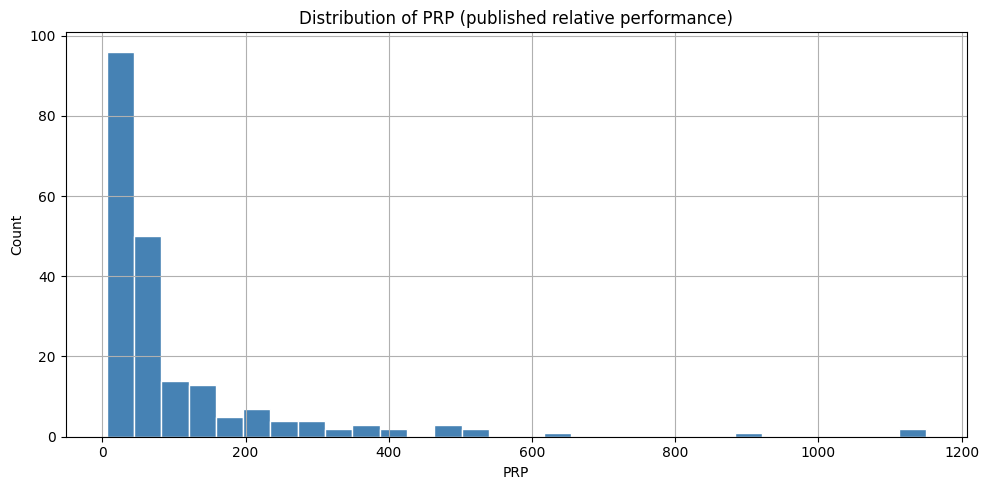

In [59]:
# The actual performance of the CPUs after hitting the markets
print(df["PRP"].describe().round(1))

df["PRP"].hist(bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of PRP (published relative performance)")
plt.xlabel("PRP")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

highly right-skewed data
The Performance of some chips are relatively very high to the others, making it hard to predict them accurately without standardisation

Top Vendors

VendorName
ibm          32
nas          19
ncr          13
honeywell    13
sperry       13
siemens      12
amdahl        9
cdc           9
burroughs     8
hp            7
Name: count, dtype: int64


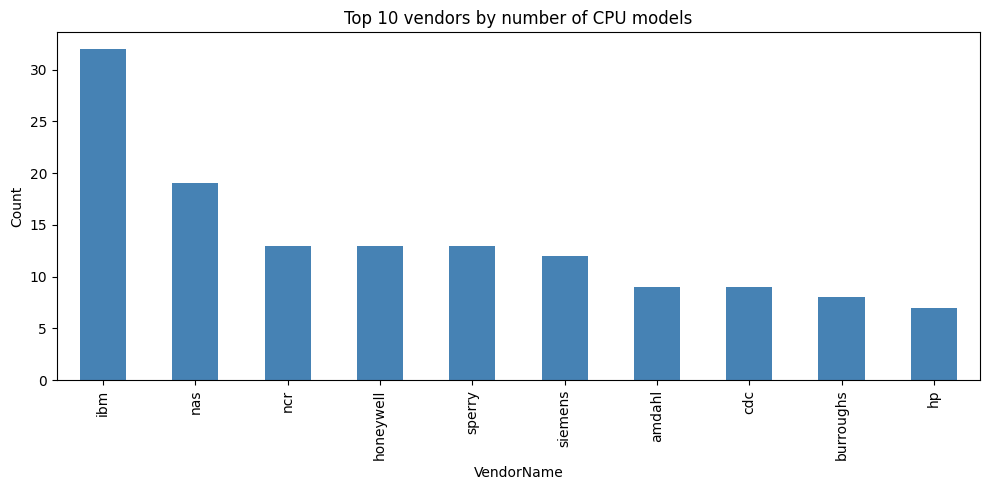

In [21]:
top_vendors = df["VendorName"].value_counts().head(10)
print(top_vendors)

top_vendors.plot(kind="bar", color="steelblue")
plt.title("Top 10 vendors by number of CPU models")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

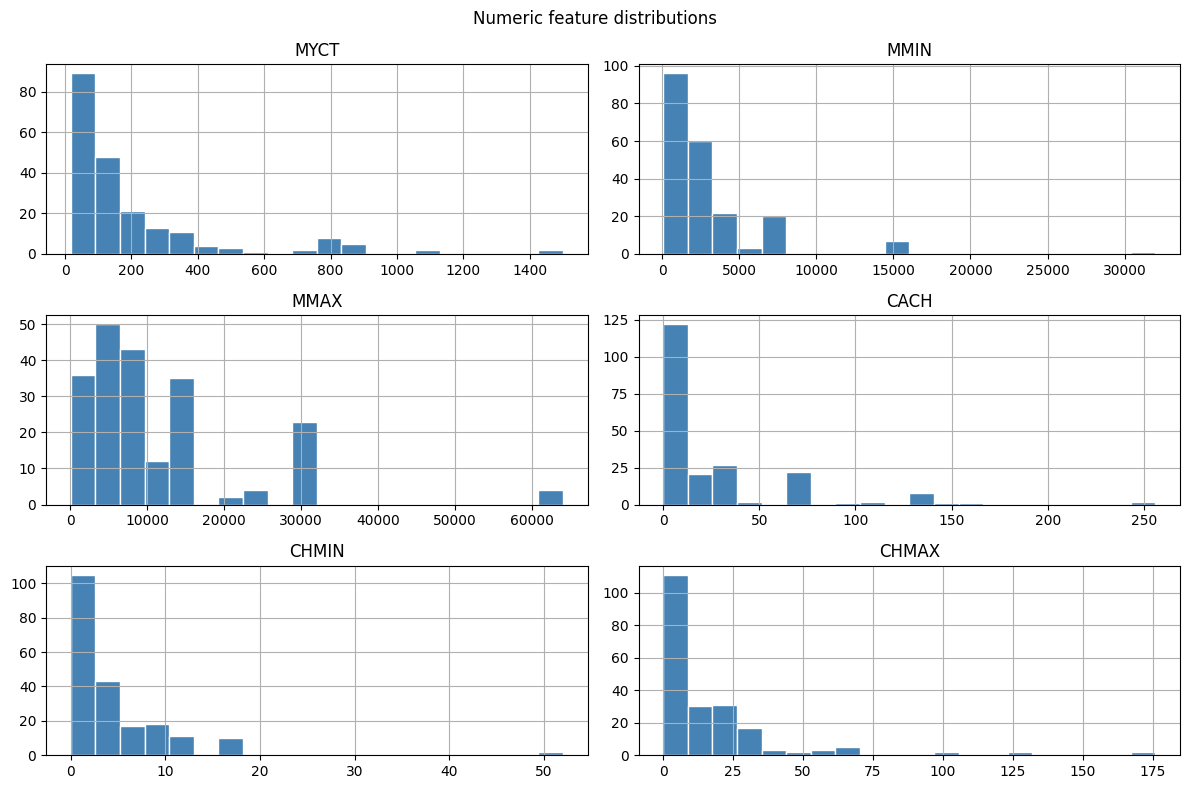

In [22]:
numeric_cols = ["MYCT", "MMIN", "MMAX", "CACH", "CHMIN", "CHMAX"]

df[numeric_cols].hist(bins=20, figsize=(12, 8), color="steelblue", edgecolor="white")
plt.suptitle("Numeric feature distributions")
plt.tight_layout()
plt.show()

This shows us that all features are positively skewed

In [23]:
correlations = df[numeric_cols + ["PRP"]].corr()["PRP"].sort_values(ascending=False)
print("Correlation of each numeric feature with PRP:")
print(correlations.round(3))

Correlation of each numeric feature with PRP:
PRP      1.000
MMAX     0.863
MMIN     0.795
CACH     0.663
CHMIN    0.609
CHMAX    0.605
MYCT    -0.307
Name: PRP, dtype: float64


This shows that the actual performance of a CPU is highly correlated to the amount of memory it has

### Performance per vendor

In [24]:
vendor_perf = (
    df.groupby("VendorName")["PRP"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .head(15)
    .round(1)
)
print(vendor_perf)

             mean  count
VendorName              
amdahl      416.3      9
sperry      254.9     13
adviser     198.0      1
gould       182.3      3
nas         176.9     19
cdc         130.1      9
siemens     121.8     12
basf        115.0      2
ibm          85.1     32
ipl          69.0      6
ncr          63.3     13
honeywell    60.5     13
wang         56.0      2
dg           54.1      7
prime        53.8      5


In [25]:
print(f"Distinct VendorName values: {df['VendorName'].nunique():,}")
print(f"Distinct ModelName values:  {df['ModelName'].nunique():,}")

Distinct VendorName values: 30
Distinct ModelName values:  209


## Preprocessing

In [26]:
# Keep ERP in a separate variable so we can compare to it later
erp_truth = df["ERP"].copy()

# Drop ModelName because of its high cardinality
data = df.drop(columns=["ModelName", "ERP"])
print("Columns kept for modelling:", data.columns.tolist())

Columns kept for modelling: ['VendorName', 'MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX', 'PRP']


 One-hot encode VendorName

In [27]:
data = pd.get_dummies(data, columns=["VendorName"], drop_first=True)
print(f"Shape after one-hot encoding: {data.shape}")
print("Sample columns:", data.columns[:10].tolist())


Shape after one-hot encoding: (209, 36)
Sample columns: ['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX', 'PRP', 'VendorName_amdahl', 'VendorName_apollo', 'VendorName_basf']


Train and test split (80/20)  

In [28]:
from sklearn.model_selection import train_test_split

# Dropping the actual performance, not used in training.
X = data.drop(columns=["PRP"])
y = data["PRP"]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, X.index,
    test_size=0.2,
    random_state=RANDOM_SEED
)

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")

Train size: 167
Test size:  42


In [29]:
# Scale Numeric features
from sklearn.preprocessing import StandardScaler

numeric_cols = ["MYCT", "MMIN", "MMAX", "CACH", "CHMIN", "CHMAX"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# testing data is scaled only using the mean and standard Deviation from the training data
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Sample scaled values:")
print(X_train_scaled[numeric_cols].head().round(2))

Sample scaled values:
     MYCT  MMIN  MMAX  CACH  CHMIN  CHMAX
150 -0.62  1.55  0.42  0.18   0.65  -0.06
96  -0.68  3.93  1.90  0.95   0.65   0.29
199 -0.66  1.55  4.86  2.49   1.35   6.78
68  -0.38 -0.53 -0.69 -0.60  -0.22   0.29
156 -0.66  3.93  1.90  5.58   2.04   0.29


## Linear Regression
Applying this to see how good a basic model is when compared to ERP


#### 1. with Standard Scaling


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

pred_linreg = linreg.predict(X_test_scaled)

linreg_rmse = np.sqrt(mean_squared_error(y_test, pred_linreg))
linreg_r2 = r2_score(y_test, pred_linreg)

print(f"Our Linear Regression  RMSE: {linreg_rmse:.2f}")
print(f"Our Linear Regression  R²:   {linreg_r2:.4f}")

Our Linear Regression  RMSE: 93.88
Our Linear Regression  R²:   0.8269


### Compare to ERP on the same test rows

In [31]:
erp_test = erp_truth.loc[idx_test]
erp_rmse_test = np.sqrt(mean_squared_error(y_test, erp_test))
erp_r2_test = r2_score(y_test, erp_test)

print(f"1987 baseline (ERP) on test rows  RMSE: {erp_rmse_test:.2f}")
print(f"1987 baseline (ERP) on test rows  R²:   {erp_r2_test:.4f}")

1987 baseline (ERP) on test rows  RMSE: 40.82
1987 baseline (ERP) on test rows  R²:   0.9673


Our basic Model is significantly worse than the ERP as ERP is a more Sophesticated method of linear regression as mentioned in their research papers [here](http://semanticscholar.org/reader/d1d8c4a1330a8205a618431a6646117468600140)

#### 2. with Log Transform

In [32]:
# Log-transform the target to handle right skew
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

linreg_log = LinearRegression()
linreg_log.fit(X_train_scaled, y_train_log)

# Back-transform predictions to the original PRP scale before evaluation
pred_linreg_log = np.expm1(linreg_log.predict(X_test_scaled))

linreg_log_rmse = np.sqrt(mean_squared_error(y_test, pred_linreg_log))
linreg_log_r2   = r2_score(y_test, pred_linreg_log)

print(f"Linear Regression (Log Transform)  RMSE: {linreg_log_rmse:.2f}")
print(f"Linear Regression (Log Transform)  R²:   {linreg_log_r2:.4f}")

Linear Regression (Log Transform)  RMSE: 824.01
Linear Regression (Log Transform)  R²:   -12.3381


Due to highly right skewed data R squared went completely out of place


### Neural Network
Linear Regression has not performed well. let's see how good Neural network model works


In [42]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=RANDOM_SEED,
    early_stopping=True,
    validation_fraction=0.15
)
mlp.fit(X_train_scaled, y_train)

pred_mlp = mlp.predict(X_test_scaled)

mlp_rmse = np.sqrt(mean_squared_error(y_test, pred_mlp))
mlp_r2 = r2_score(y_test, pred_mlp)

print(f"MLP Neural Network  RMSE: {mlp_rmse:.2f}")
print(f"MLP Neural Network  R²:   {mlp_r2:.4f}")

MLP Neural Network  RMSE: 91.27
MLP Neural Network  R²:   0.8364


This is the best this Neural Network can perform, going above 500 iterations doesn't change the outcome


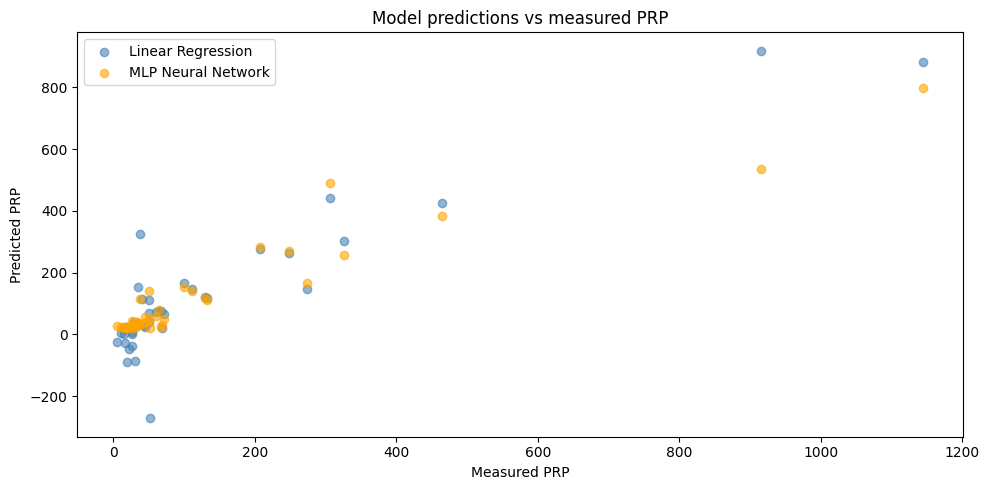

In [57]:
plt.scatter(y_test, pred_linreg, alpha=0.6, label="Linear Regression", color="steelblue")
plt.scatter(y_test, pred_mlp,    alpha=0.6, label="MLP Neural Network", color="orange")
plt.title("Model predictions vs measured PRP")
plt.xlabel("Measured PRP")
plt.ylabel("Predicted PRP")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
test_results = pd.DataFrame({
    "Model": [
        "1987 ERP baseline",
        "Linear Regression (StandardScaler)",
        "Linear Regression (Log Transform)",
        "MLP Neural Network"
    ],
    "RMSE": [
        round(erp_rmse_test,   2),
        round(linreg_rmse,     2),
        round(linreg_log_rmse, 2),
        round(mlp_rmse,        2)
    ],
    "R²": [
        round(erp_r2_test,   4),
        round(linreg_r2,     4),
        round(linreg_log_r2, 4),
        round(mlp_r2,        4)
    ]
})

test_results

,Model,RMSE,R²
0,1987 ERP baseline,40.82,0.9673
1,Linear Regression (StandardScaler),93.88,0.8269
2,Linear Regression (Log Transform),824.01,-12.3381
3,MLP Neural Network,91.27,0.8364


In [36]:
coefficients = pd.Series(linreg.coef_, index=X_train_scaled.columns)

# Top 10 features that push PRP UP
top_positive = coefficients.sort_values(ascending=False).head(10)
print("Top 10 features that raise predicted PRP:")
print(top_positive.round(2))
print()

# Top 10 features that push PRP DOWN
top_negative = coefficients.sort_values().head(10)
print("Top 10 features that lower predicted PRP:")
print(top_negative.round(2))

Top 10 features that raise predicted PRP:
VendorName_wang            379.63
VendorName_dg              370.70
VendorName_apollo          369.61
VendorName_nixdorf         368.26
VendorName_bti             365.35
VendorName_c.r.d           362.70
VendorName_dec             353.41
VendorName_prime           351.33
VendorName_perkin-elmer    351.30
VendorName_sperry          347.00
dtype: float64

Top 10 features that lower predicted PRP:
CHMIN                    -8.22
VendorName_microdata     -0.98
VendorName_sratus         0.00
MYCT                      5.59
CACH                     28.39
MMAX                     40.37
MMIN                     50.73
CHMAX                    71.60
VendorName_burroughs    221.18
VendorName_honeywell    274.87
dtype: float64
